# NT Connect — Historical Cyclone Track Analysis

This notebook adds **historical cyclone-track exposure context** to the NT Connect project.

It is designed to work with your current Windows project folder:

`C:\Users\HP\OneDrive\เอกสาร\remote-connectivity`

The notebook now:
- auto-detects `remote-connectivity` or `remote_connectivity`
- automatically finds the BOM cyclone CSV in `data/raw`
- automatically finds the existing cleaned NT mobile dataset
- validates required columns before analysis
- uses projected distance calculations in kilometres
- exports app-ready cyclone-enriched data
- gives clear diagnostic messages when a file is missing

> **Important:** This is historical cyclone-track exposure context, not a prediction of future cyclone risk.

## 1. Imports and automatic project setup

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt

from shapely.geometry import Point, LineString

# ------------------------------------------------------------
# PROJECT ROOT
# ------------------------------------------------------------
# Your actual current project folder uses a hyphen:
# remote-connectivity
#
# The second path is kept as a fallback in case the folder is
# renamed later.
# ------------------------------------------------------------

PROJECT_CANDIDATES = [
    Path(r"C:\Users\HP\OneDrive\เอกสาร\remote-connectivity"),
    Path(r"C:\Users\HP\OneDrive\เอกสาร\remote_connectivity"),
]

PROJECT_ROOT = next(
    (p for p in PROJECT_CANDIDATES if p.exists()),
    None
)

if PROJECT_ROOT is None:
    raise FileNotFoundError(
        "Could not find the NT Connect project folder.\n\n"
        "Expected one of:\n"
        r"C:\Users\HP\OneDrive\เอกสาร\remote-connectivity" + "\n"
        r"C:\Users\HP\OneDrive\เอกสาร\remote_connectivity" + "\n\n"
        "If your project is somewhere else, update PROJECT_CANDIDATES in this cell."
    )

RAW_DIR = PROJECT_ROOT / "data" / "raw"
CLEAN_DIR = PROJECT_ROOT / "data" / "cleaned"
APP_DATA_DIR = PROJECT_ROOT / "data" / "app"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

for folder in [RAW_DIR, CLEAN_DIR, APP_DATA_DIR, OUTPUT_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

print("✅ Project found")
print("PROJECT_ROOT:", PROJECT_ROOT)
print("RAW_DIR:", RAW_DIR)
print("CLEAN_DIR:", CLEAN_DIR)
print("APP_DATA_DIR:", APP_DATA_DIR)
print("OUTPUT_DIR:", OUTPUT_DIR)

✅ Project found
PROJECT_ROOT: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity
RAW_DIR: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\raw
CLEAN_DIR: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\cleaned
APP_DATA_DIR: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\app
OUTPUT_DIR: C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\outputs


## 2. Inspect the raw-data folder

In [2]:
print("Files currently inside data/raw:\n")

raw_items = sorted(RAW_DIR.iterdir())

for item in raw_items:
    kind = "DIR " if item.is_dir() else "FILE"
    print(f"{kind:4}  {item.name}")

if not raw_items:
    print("⚠️ data/raw is empty.")

Files currently inside data/raw:

DIR   ASGS_Ed3_2021_RA_GPKG_GDA2020
FILE  ASGS_Ed3_2021_RA_GPKG_GDA2020.zip
FILE  bom_tropical_cyclone_tracks.csv
FILE  Mobile Infrastructure Report 2025 - output tables.xlsx
FILE  mobile-coverage-all-sites.xlsx
FILE  mobile_black_spots.geojson.txt
DIR   nbn_coverage_fixedline_2024-03-26
FILE  nbn_coverage_fixedline_2024-03-26.zip
FILE  Population change by capital city.csv


## 3. Automatically locate the BOM cyclone CSV

The preferred filename is:

`bom_tropical_cyclone_tracks.csv`

If the name differs slightly, the notebook searches for CSV files containing words such as `cyclone`, `tropical`, or `IDCKMSTM0S`.

In [3]:
preferred_cyclone = RAW_DIR / "bom_tropical_cyclone_tracks.csv"

if preferred_cyclone.exists():
    cyclone_file = preferred_cyclone
else:
    csv_files = list(RAW_DIR.glob("*.csv"))

    likely = [
        p for p in csv_files
        if any(
            keyword in p.name.lower()
            for keyword in ["cyclone", "tropical", "idckmstm0s"]
        )
    ]

    if likely:
        cyclone_file = likely[0]
    else:
        raise FileNotFoundError(
            "No BOM cyclone CSV could be found in:\n"
            f"{RAW_DIR}\n\n"
            "CSV files found:\n"
            + "\n".join(f"- {p.name}" for p in csv_files)
            + "\n\nExpected something like: bom_tropical_cyclone_tracks.csv"
        )

print("✅ Cyclone file found:")
print(cyclone_file)
print("File size:", round(cyclone_file.stat().st_size / 1024 / 1024, 2), "MB")

✅ Cyclone file found:
C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\raw\bom_tropical_cyclone_tracks.csv
File size: 7.56 MB


## 4. Load the BOM cyclone file safely

### Why header detection is needed

The BOM download includes several descriptive metadata lines before the actual CSV table.
The notebook now searches for the header containing `DISTURBANCE_ID`, `TM`, `LAT`, and `LON`, then reads the table from that row onward.

In [4]:
# ------------------------------------------------------------
# LOAD BOM CSV WITH AUTOMATIC HEADER DETECTION
# ------------------------------------------------------------
# The BOM file can contain several metadata/preamble lines before
# the actual 79-column CSV header. We scan the first part of the
# file and find the row containing the real field names.
# ------------------------------------------------------------

def detect_bom_header_row(path, max_lines=30):
    encodings = ["utf-8-sig", "utf-8", "latin-1"]

    for encoding in encodings:
        try:
            with open(path, "r", encoding=encoding, errors="strict") as f:
                for line_number, line in enumerate(f):
                    if line_number >= max_lines:
                        break

                    upper = line.upper()

                    # The real BOM header should contain these fields.
                    if (
                        "DISTURBANCE_ID" in upper
                        and "TM" in upper
                        and "LAT" in upper
                        and "LON" in upper
                    ):
                        return line_number, encoding

        except UnicodeDecodeError:
            continue

    raise RuntimeError(
        "Could not find the real BOM CSV header within the first "
        f"{max_lines} lines of:\n{path}\n\n"
        "Open the file in a text editor and check where the row "
        "containing DISTURBANCE_ID, TM, LAT and LON appears."
    )


header_row, detected_encoding = detect_bom_header_row(
    cyclone_file
)

print("✅ BOM header detected")
print("Header row (0-based):", header_row)
print("Encoding:", detected_encoding)

cyclones_raw = pd.read_csv(
    cyclone_file,
    skiprows=header_row,
    encoding=detected_encoding,
    low_memory=False
)

print("\n✅ Cyclone CSV loaded")
print("Shape:", cyclones_raw.shape)

print("\nFirst 20 columns:")
print(cyclones_raw.columns.tolist()[:20])

display(cyclones_raw.head())

✅ BOM header detected
Header row (0-based): 4
Encoding: utf-8-sig

✅ Cyclone CSV loaded
Shape: (31706, 79)

First 20 columns:
['NAME', 'DISTURBANCE_ID', 'TM', 'TYPE', 'DATA_SRC', 'SURFACE_CODE', 'CYC_TYPE', 'LAT', 'LON', 'POSITION_METHOD', 'POSITION_UNCERTAINTY', 'DVORAK_DATA_T_NO', 'DVORAK_MODEL_T_NO', 'DVORAK_PATTERN_T_NO', 'DVORAK_FINAL_T_NO', 'DVORAK_CI_NO', 'CENTRAL_PRES', 'CENTRAL_PRES_UNCERTAINTY', 'CENTRAL_PRES_METHOD', 'PRES_WIND_RELATION_USED']


,NAME,DISTURBANCE_ID,TM,TYPE,DATA_SRC,SURFACE_CODE,CYC_TYPE,LAT,LON,POSITION_METHOD,...,MAX_REP_SWL_PER,MAX_REP_SWL_METHOD,MAX_REP_SWL_LON,MAX_REP_SWL_LAT,MAX_REP_TIDE_ANOM,MAX_REP_TIDE_ANOM_UNCERTAINTY,MAX_REP_TIDE_ANOM_METHOD,MAX_REP_TIDE_ANOM_LON,MAX_REP_TIDE_ANOM_LAT,COMMENT
0,unnamed,AU190607_01U,1907-01-17 23:00,T,,1,,-13.0,146.5,,...,,,,,,,,,,Imported from CYCARD; June 2009
1,unnamed,AU190607_01U,1907-01-18 23:00,T,,3,,-15.0,145.0,,...,,,,,,,,,,Imported from CYCARD; June 2009
2,unnamed,AU190607_01U,1907-01-19 23:00,T,,2,,-14.0,143.0,,...,,,,,,,,,,Imported from CYCARD; June 2009
3,unnamed,AU190607_01U,1907-01-20 23:00,T,,2,,-13.5,142.0,,...,,,,,,,,,,Imported from CYCARD; June 2009
4,unnamed,AU190607_01U,1907-01-21 23:00,T,,4,,-15.6,141.5,,...,,,,,,,,,,Imported from CYCARD; June 2009


## 5. Standardise and validate cyclone columns

We need these fields:

- `DISTURBANCE_ID`
- `TM`
- `LAT`
- `LON`

Optional but useful:
- `NAME`
- `TYPE`
- `CYC_TYPE`

In [5]:
cyclones = cyclones_raw.copy()

cyclones.columns = (
    cyclones.columns
    .astype(str)
    .str.strip()
    .str.upper()
)

required = ["DISTURBANCE_ID", "TM", "LAT", "LON"]
missing_required = [c for c in required if c not in cyclones.columns]

if missing_required:
    raise ValueError(
        "The BOM file loaded, but required columns are missing.\n\n"
        f"Missing: {missing_required}\n\n"
        f"Columns available:\n{cyclones.columns.tolist()}"
    )

if "NAME" not in cyclones.columns:
    cyclones["NAME"] = pd.NA

if "CYC_TYPE" not in cyclones.columns:
    cyclones["CYC_TYPE"] = np.nan

print("✅ Required BOM columns are present.")

✅ Required BOM columns are present.


## 6. Clean cyclone observations

In [6]:
cyclones["TM"] = pd.to_datetime(
    cyclones["TM"],
    errors="coerce",
    utc=True
)

cyclones["LAT"] = pd.to_numeric(
    cyclones["LAT"],
    errors="coerce"
)

cyclones["LON"] = pd.to_numeric(
    cyclones["LON"],
    errors="coerce"
)

cyclones["CYC_TYPE"] = pd.to_numeric(
    cyclones["CYC_TYPE"],
    errors="coerce"
)

before = len(cyclones)

cyclones = cyclones.dropna(
    subset=["DISTURBANCE_ID", "TM", "LAT", "LON"]
).copy()

# Broad sanity bounds for the Australian-region cyclone database.
cyclones = cyclones[
    cyclones["LAT"].between(-50, 0)
    & cyclones["LON"].between(90, 180)
].copy()

# Use a more consistent modern observation period.
cyclones = cyclones[
    cyclones["TM"].dt.year >= 1970
].copy()

# If TYPE exists and actually contains tropical cyclone records,
# retain those. If the field uses a different coding scheme,
# do not delete the whole dataset.
if "TYPE" in cyclones.columns:
    type_values = (
        cyclones["TYPE"]
        .dropna()
        .astype(str)
        .str.strip()
        .str.upper()
    )

    if type_values.eq("T").any():
        cyclones = cyclones[
            cyclones["TYPE"]
            .astype(str)
            .str.strip()
            .str.upper()
            .eq("T")
        ].copy()

cyclones = cyclones.sort_values(
    ["DISTURBANCE_ID", "TM"]
).reset_index(drop=True)

print("Rows before cleaning:", before)
print("Rows after cleaning:", len(cyclones))
print("Distinct disturbance IDs:", cyclones["DISTURBANCE_ID"].nunique())
print("Date range:", cyclones["TM"].min(), "→", cyclones["TM"].max())
print("CYC_TYPE 40 observations:", int(cyclones["CYC_TYPE"].eq(40).sum()))

display(
    cyclones[
        ["DISTURBANCE_ID", "NAME", "TM", "LAT", "LON", "CYC_TYPE"]
    ].head(10)
)

Rows before cleaning: 31706
Rows after cleaning: 22847
Distinct disturbance IDs: 625
Date range: 1970-01-02 23:00:00+00:00 → 2026-04-12 12:00:00+00:00
CYC_TYPE 40 observations: 3936


,DISTURBANCE_ID,NAME,TM,LAT,LON,CYC_TYPE
0,AU196970_02U,ADA,1970-01-02 23:00:00+00:00,-15.8,165.1,NaN
1,AU196970_02U,ADA,1970-01-03 11:00:00+00:00,-16.1,163.5,NaN
2,AU196970_02U,ADA,1970-01-03 23:00:00+00:00,-16.4,162.1,NaN
3,AU196970_02U,ADA,1970-01-04 11:00:00+00:00,-16.8,160.6,NaN
4,AU196970_02U,ADA,1970-01-04 23:00:00+00:00,-17.0,159.2,NaN
5,AU196970_02U,ADA,1970-01-05 11:00:00+00:00,-17.0,158.0,NaN
6,AU196970_02U,ADA,1970-01-05 23:00:00+00:00,-16.7,156.6,NaN
7,AU196970_02U,ADA,1970-01-06 11:00:00+00:00,-16.4,156.2,NaN
8,AU196970_02U,ADA,1970-01-06 23:00:00+00:00,-16.0,155.9,NaN
9,AU196970_02U,ADA,1970-01-07 11:00:00+00:00,-15.5,155.9,NaN


## 7. Create one geographic track per cyclone

We connect consecutive observations belonging to the same disturbance.

Distance analysis is then done using **Australian Albers (EPSG:3577)** rather than degrees.

In [7]:
def build_track_geometry(group):
    coords = list(
        zip(
            group["LON"].astype(float),
            group["LAT"].astype(float)
        )
    )

    # Remove consecutive duplicate coordinates.
    cleaned = []

    for coord in coords:
        if not cleaned or coord != cleaned[-1]:
            cleaned.append(coord)

    if len(cleaned) >= 2:
        return LineString(cleaned)

    if len(cleaned) == 1:
        return Point(cleaned[0])

    return None


track_records = []

for disturbance_id, group in cyclones.groupby(
    "DISTURBANCE_ID",
    sort=False
):
    group = group.sort_values("TM")

    geometry = build_track_geometry(group)

    if geometry is None:
        continue

    names = (
        group["NAME"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    valid_names = names[
        ~names.str.lower().isin(
            ["nan", "none", "unnamed", ""]
        )
    ]

    cyclone_name = (
        valid_names.iloc[0]
        if len(valid_names)
        else str(disturbance_id)
    )

    track_records.append({
        "disturbance_id": disturbance_id,
        "cyclone_name": cyclone_name,
        "track_start": group["TM"].min(),
        "track_end": group["TM"].max(),
        "geometry": geometry,
    })

tracks = gpd.GeoDataFrame(
    track_records,
    geometry="geometry",
    crs="EPSG:4326"
)

if tracks.empty:
    raise ValueError(
        "No cyclone track geometries could be created."
    )

tracks_3577 = tracks.to_crs("EPSG:3577")

print("✅ Cyclone tracks created:", len(tracks))
display(tracks.head())

✅ Cyclone tracks created: 625


,disturbance_id,cyclone_name,track_start,track_end,geometry
0,AU196970_02U,ADA,1970-01-02 23:00:00+00:00,1970-01-18 11:00:00+00:00,"LINESTRING (165.1 -15.8, 163.5 -16.1, 162.1 -1..."
1,AU196970_03U,GLYNIS,1970-01-26 23:30:00+00:00,1970-02-06 01:00:00+00:00,"LINESTRING (129.8 -12.1, 127.7 -12.7, 126.5 -1..."
2,AU196970_04U,INGRID,1970-02-09 16:00:00+00:00,1970-02-17 01:00:00+00:00,"LINESTRING (123.3 -16, 122.2 -14, 121 -14, 119..."
3,AU196970_05U,DAWN,1970-02-10 05:00:00+00:00,1970-02-19 05:00:00+00:00,"LINESTRING (138.5 -13.9, 139.5 -13.1, 141.8 -1..."
4,AU196970_06U,FLORENCE,1970-02-10 23:00:00+00:00,1970-02-12 20:00:00+00:00,"LINESTRING (154.5 -14.1, 154.8 -14.8, 154.9 -1..."


## 8. Create severe-cyclone track segments

For this prototype, `CYC_TYPE = 40` is treated as the severe-track indicator used in the BOM structure we are working from.

Only observations recorded at that level are used for the severe-track proximity feature.

In [8]:
severe_obs = cyclones[
    cyclones["CYC_TYPE"].eq(40)
].copy()

severe_records = []

for disturbance_id, group in severe_obs.groupby(
    "DISTURBANCE_ID",
    sort=False
):
    group = group.sort_values("TM")

    geometry = build_track_geometry(group)

    if geometry is None:
        continue

    names = (
        group["NAME"]
        .dropna()
        .astype(str)
        .str.strip()
    )

    valid_names = names[
        ~names.str.lower().isin(
            ["nan", "none", "unnamed", ""]
        )
    ]

    cyclone_name = (
        valid_names.iloc[0]
        if len(valid_names)
        else str(disturbance_id)
    )

    severe_records.append({
        "disturbance_id": disturbance_id,
        "cyclone_name": cyclone_name,
        "geometry": geometry,
    })

if severe_records:
    severe_tracks = gpd.GeoDataFrame(
        severe_records,
        geometry="geometry",
        crs="EPSG:4326"
    )
    severe_tracks_3577 = severe_tracks.to_crs(
        "EPSG:3577"
    )
else:
    severe_tracks = gpd.GeoDataFrame(
        columns=[
            "disturbance_id",
            "cyclone_name",
            "geometry"
        ],
        geometry="geometry",
        crs="EPSG:4326"
    )
    severe_tracks_3577 = severe_tracks.to_crs(
        "EPSG:3577"
    )

print(
    "Cyclones containing CYC_TYPE 40 observations:",
    len(severe_tracks)
)

Cyclones containing CYC_TYPE 40 observations: 295


## 9. Automatically locate the existing NT Connect mobile dataset

The notebook checks for the main enriched file first, then searches `data/cleaned` for a suitable mobile coverage CSV.

In [9]:
preferred_mobile_files = [
    CLEAN_DIR / "nt_mobile_coverage_enriched.csv",
    CLEAN_DIR / "nt_mobile_coverage_with_blackspots.csv",
]

mobile_file = next(
    (p for p in preferred_mobile_files if p.exists()),
    None
)

if mobile_file is None:
    candidates = [
        p for p in CLEAN_DIR.glob("*.csv")
        if (
            "mobile" in p.name.lower()
            and "coverage" in p.name.lower()
            and "cyclone" not in p.name.lower()
        )
    ]

    if not candidates:
        raise FileNotFoundError(
            "Could not locate the cleaned mobile coverage CSV in:\n"
            f"{CLEAN_DIR}\n\n"
            "Run nt_connect.ipynb first so the cleaned dataset is exported."
        )

    mobile_file = candidates[0]

print("✅ Mobile dataset found:")
print(mobile_file)

✅ Mobile dataset found:
C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\cleaned\nt_mobile_coverage_enriched.csv


## 10. Load and validate NT locations

In [10]:
mobile = pd.read_csv(
    mobile_file,
    low_memory=False
)

mobile.columns = (
    mobile.columns
    .astype(str)
    .str.strip()
    .str.lower()
    .str.replace(" ", "_", regex=False)
)

required_mobile = [
    "site_name",
    "latitude",
    "longitude"
]

missing_mobile = [
    c for c in required_mobile
    if c not in mobile.columns
]

if missing_mobile:
    raise ValueError(
        "The mobile dataset was found, but required columns are missing.\n\n"
        f"Missing: {missing_mobile}\n"
        f"Available: {mobile.columns.tolist()}"
    )

mobile["latitude"] = pd.to_numeric(
    mobile["latitude"],
    errors="coerce"
)

mobile["longitude"] = pd.to_numeric(
    mobile["longitude"],
    errors="coerce"
)

bad_coords = (
    mobile["latitude"].isna()
    | mobile["longitude"].isna()
)

if bad_coords.any():
    print(
        "⚠️ Dropping rows with invalid coordinates:",
        int(bad_coords.sum())
    )

mobile = mobile.loc[
    ~bad_coords
].copy().reset_index(drop=True)

mobile_gdf = gpd.GeoDataFrame(
    mobile,
    geometry=gpd.points_from_xy(
        mobile["longitude"],
        mobile["latitude"]
    ),
    crs="EPSG:4326"
)

mobile_3577 = mobile_gdf.to_crs(
    "EPSG:3577"
)

print("✅ NT locations ready:", len(mobile))
display(
    mobile[
        ["site_name", "latitude", "longitude"]
    ].head()
)

✅ NT locations ready: 188


,site_name,latitude,longitude
0,ADELAIDE RIVER,-13.23780,131.10473
1,AILERON STATION,-22.50000,133.24500
2,ALAMIRRA,-11.06700,132.52800
3,ALI CURUNG,-21.00333,134.40694
4,ALPURRURULAM,-20.98417,137.84749


## 11. Calculate historical cyclone-track exposure context

For every NT location we calculate:

- nearest historical track
- distance to nearest track
- distinct cyclone tracks within 100 km
- distinct cyclone tracks within 200 km
- severe-track count within 200 km
- nearest severe-track distance
- most recent cyclone track within 200 km

In [11]:
results = []

for _, location in mobile_3577.iterrows():
    point = location.geometry

    distances_km = (
        tracks_3577.geometry.distance(point)
        / 1000.0
    )

    nearest_index = distances_km.idxmin()
    nearest_track = tracks_3577.loc[
        nearest_index
    ]

    within_100 = tracks_3577.loc[
        distances_km <= 100
    ]

    within_200 = tracks_3577.loc[
        distances_km <= 200
    ]

    if len(severe_tracks_3577) > 0:
        severe_distances_km = (
            severe_tracks_3577.geometry.distance(point)
            / 1000.0
        )

        severe_within_200 = severe_tracks_3577.loc[
            severe_distances_km <= 200
        ]

        severe_count = int(
            severe_within_200[
                "disturbance_id"
            ].nunique()
        )

        nearest_severe_km = float(
            severe_distances_km.min()
        )
    else:
        severe_count = 0
        nearest_severe_km = np.nan

    if len(within_200) > 0:
        latest = (
            within_200
            .sort_values("track_end")
            .iloc[-1]
        )

        latest_name = latest[
            "cyclone_name"
        ]

        latest_date = latest[
            "track_end"
        ]
    else:
        latest_name = pd.NA
        latest_date = pd.NaT

    results.append({
        "cyclone_nearest_name":
            nearest_track["cyclone_name"],

        "cyclone_nearest_id":
            nearest_track["disturbance_id"],

        "cyclone_nearest_track_km":
            round(
                float(
                    distances_km.loc[
                        nearest_index
                    ]
                ),
                1
            ),

        "cyclones_within_100km":
            int(
                within_100[
                    "disturbance_id"
                ].nunique()
            ),

        "cyclones_within_200km":
            int(
                within_200[
                    "disturbance_id"
                ].nunique()
            ),

        "severe_cyclones_within_200km":
            severe_count,

        "nearest_severe_track_km":
            (
                round(
                    nearest_severe_km,
                    1
                )
                if np.isfinite(
                    nearest_severe_km
                )
                else np.nan
            ),

        "latest_cyclone_within_200km":
            latest_name,

        "latest_cyclone_within_200km_date":
            latest_date,
    })

cyclone_features = pd.DataFrame(
    results
)

mobile_cyclone = pd.concat(
    [
        mobile.reset_index(drop=True),
        cyclone_features.reset_index(
            drop=True
        )
    ],
    axis=1
)

print(
    "✅ Cyclone features calculated for",
    len(mobile_cyclone),
    "NT locations"
)

display(
    mobile_cyclone[
        [
            "site_name",
            "cyclone_nearest_name",
            "cyclone_nearest_track_km",
            "cyclones_within_100km",
            "cyclones_within_200km",
            "severe_cyclones_within_200km",
            "latest_cyclone_within_200km"
        ]
    ].head(10)
)

✅ Cyclone features calculated for 188 NT locations


,site_name,cyclone_nearest_name,cyclone_nearest_track_km,cyclones_within_100km,cyclones_within_200km,severe_cyclones_within_200km,latest_cyclone_within_200km
0,ADELAIDE RIVER,Carlos,4.7,24,51,5,Narelle
1,AILERON STATION,GRETA,68.3,1,2,0,GRETA
2,ALAMIRRA,SID,8.9,26,45,6,Fina
3,ALI CURUNG,Ellie,9.7,5,6,0,Ellie
4,ALPURRURULAM,Trevor,1.9,2,5,0,Kirrily
5,AMOONGUNA,GRETA,44.1,1,2,0,GRETA
6,AMPILATWATJA,Ellie,55.3,2,4,0,Ellie
7,ANGATYEPE,GRETA,23.8,1,2,0,GRETA
8,ANGURUGU,JASON,1.9,28,57,10,Narelle
9,ARLPARRA,ALAN,44.0,1,4,0,Ellie


## 12. Create a transparent Cyclone Exposure Context Score

This is **illustrative**, not a scientific hazard or risk model.

Score components:

- 50% nearest historical track proximity
- 30% number of distinct tracks within 200 km
- 20% number of severe-track encounters within 200 km

### Why the scoring method changed

The first run showed that **182 of 188 locations have a historical cyclone track within 100 km** and **all 188 have one within 200 km**. That means fixed distance thresholds make the score saturate and provide weak discrimination.

The final notebook therefore uses **relative percentile scoring across the NT locations in this project**. This makes the metric useful for comparing historical exposure context while remaining explicit that it is **not an absolute cyclone-risk estimate**.

In [12]:
# ------------------------------------------------------------
# RELATIVE CYCLONE EXPOSURE CONTEXT SCORE
# ------------------------------------------------------------
# The first threshold-based score saturated because almost every
# NT location lies close to at least one historical cyclone track.
#
# We therefore use within-dataset percentile ranks so the score
# is useful for COMPARING NT locations, not pretending to be an
# absolute cyclone-risk probability.
#
# Higher score = relatively greater historical cyclone-track
# exposure among the 188 NT locations in this project.
# ------------------------------------------------------------

# Lower distance is stronger exposure, so reverse the percentile.
mobile_cyclone["cyclone_distance_percentile"] = (
    mobile_cyclone["cyclone_nearest_track_km"]
    .rank(
        pct=True,
        ascending=False,
        method="average"
    )
    .mul(100)
)

# More distinct cyclones within 200 km = greater historical exposure.
mobile_cyclone["cyclone_frequency_percentile"] = (
    mobile_cyclone["cyclones_within_200km"]
    .rank(
        pct=True,
        ascending=True,
        method="average"
    )
    .mul(100)
)

# More severe cyclone tracks within 200 km = greater historical exposure.
mobile_cyclone["cyclone_severe_percentile"] = (
    mobile_cyclone["severe_cyclones_within_200km"]
    .rank(
        pct=True,
        ascending=True,
        method="average"
    )
    .mul(100)
)

# Transparent weights:
# 40% nearest-track proximity
# 35% historical cyclone frequency
# 25% severe-track frequency
mobile_cyclone["cyclone_exposure_context_score"] = (
    0.40 * mobile_cyclone["cyclone_distance_percentile"]
    + 0.35 * mobile_cyclone["cyclone_frequency_percentile"]
    + 0.25 * mobile_cyclone["cyclone_severe_percentile"]
).round().astype(int)

# Keep an easy-to-read category for the app.
mobile_cyclone["cyclone_exposure_context_level"] = pd.cut(
    mobile_cyclone["cyclone_exposure_context_score"],
    bins=[-1, 33, 66, 100],
    labels=["Lower", "Moderate", "Higher"]
)

display(
    mobile_cyclone[
        [
            "site_name",
            "cyclone_nearest_track_km",
            "cyclones_within_200km",
            "severe_cyclones_within_200km",
            "cyclone_exposure_context_score",
            "cyclone_exposure_context_level",
        ]
    ]
    .sort_values(
        "cyclone_exposure_context_score",
        ascending=False
    )
    .head(20)
)

,site_name,cyclone_nearest_track_km,cyclones_within_200km,severe_cyclones_within_200km,cyclone_exposure_context_score,cyclone_exposure_context_level
88,MALKALA,1.7,57,10,92,Higher
8,ANGURUGU,1.9,57,10,91,Higher
97,MILINGIMBI,0.3,50,6,91,Higher
28,BUNHANURA,0.4,49,6,90,Higher
96,MILIKAPITI,1.3,54,6,89,Higher
15,BARDALUMBA,3.3,56,10,88,Higher
49,GALIWINKU,0.6,48,6,88,Higher
55,GUNYANGARA,1.8,52,7,88,Higher
185,YUDUYUDU,2.2,52,7,87,Higher
80,KUY,0.9,57,2,87,Higher


## 13. Summary statistics

In [13]:
summary = pd.Series({
    "NT locations analysed":
        len(mobile_cyclone),

    "Median nearest cyclone track (km)":
        round(
            mobile_cyclone[
                "cyclone_nearest_track_km"
            ].median(),
            1
        ),

    "Locations with cyclone within 100 km":
        int(
            (
                mobile_cyclone[
                    "cyclones_within_100km"
                ] > 0
            ).sum()
        ),

    "Locations with cyclone within 200 km":
        int(
            (
                mobile_cyclone[
                    "cyclones_within_200km"
                ] > 0
            ).sum()
        ),

    "Locations with severe track within 200 km":
        int(
            (
                mobile_cyclone[
                    "severe_cyclones_within_200km"
                ] > 0
            ).sum()
        ),

    "Median relative exposure-context score":
        float(
            mobile_cyclone[
                "cyclone_exposure_context_score"
            ].median()
        ),

    "Maximum relative exposure-context score":
        int(
            mobile_cyclone[
                "cyclone_exposure_context_score"
            ].max()
        ),
})

display(
    summary.to_frame(
        "Value"
    )
)

,Value
NT locations analysed,188.0
Median nearest cyclone track (km),9.7
Locations with cyclone within 100 km,182.0
Locations with cyclone within 200 km,188.0
Locations with severe track within 200 km,93.0
Median relative exposure-context score,51.0
Maximum relative exposure-context score,92.0


## 14. Highest historical cyclone-track exposure context locations

In [14]:
top_cyclone_locations = (
    mobile_cyclone
    .sort_values(
        [
            "cyclone_exposure_context_score",
            "cyclones_within_200km"
        ],
        ascending=[
            False,
            False
        ]
    )
)

columns_to_show = [
    "site_name",
    "site_type",
    "population",
    "remoteness",
    "cyclone_nearest_name",
    "cyclone_nearest_track_km",
    "cyclones_within_100km",
    "cyclones_within_200km",
    "severe_cyclones_within_200km",
    "latest_cyclone_within_200km",
    "cyclone_exposure_context_score",
]

columns_to_show = [
    c for c in columns_to_show
    if c in top_cyclone_locations.columns
]

display(
    top_cyclone_locations[
        columns_to_show
    ].head(25)
)

,site_name,site_type,population,remoteness,cyclone_nearest_name,cyclone_nearest_track_km,cyclones_within_100km,cyclones_within_200km,severe_cyclones_within_200km,latest_cyclone_within_200km,cyclone_exposure_context_score
88,MALKALA,COMMUNITY,71.0,Very Remote Australia,Imogen,1.7,28,57,10,Narelle,92
8,ANGURUGU,COMMUNITY,883.0,Very Remote Australia,JASON,1.9,28,57,10,Narelle,91
97,MILINGIMBI,COMMUNITY,1025.0,Very Remote Australia,CRAIG,0.3,22,50,6,Narelle,91
28,BUNHANURA,COMMUNITY,7.0,Very Remote Australia,AU198182_04U,0.4,16,49,6,Narelle,90
96,MILIKAPITI,COMMUNITY,390.0,Very Remote Australia,BEVERLEY-EVA,1.3,33,54,6,Fina,89
15,BARDALUMBA,COMMUNITY,11.0,Very Remote Australia,Imogen,3.3,27,56,10,Narelle,88
55,GUNYANGARA,COMMUNITY,209.0,Very Remote Australia,AU198182_04U,1.8,20,52,7,Narelle,88
49,GALIWINKU,COMMUNITY,2027.0,Very Remote Australia,SID,0.6,20,48,6,Narelle,88
19,BELYUEN,COMMUNITY,150.0,Remote Australia,Carlos,2.1,34,57,6,Narelle,87
80,KUY,COMMUNITY,5.0,Very Remote Australia,GEORGE,0.9,27,57,2,Narelle,87


## 15. Visual checks

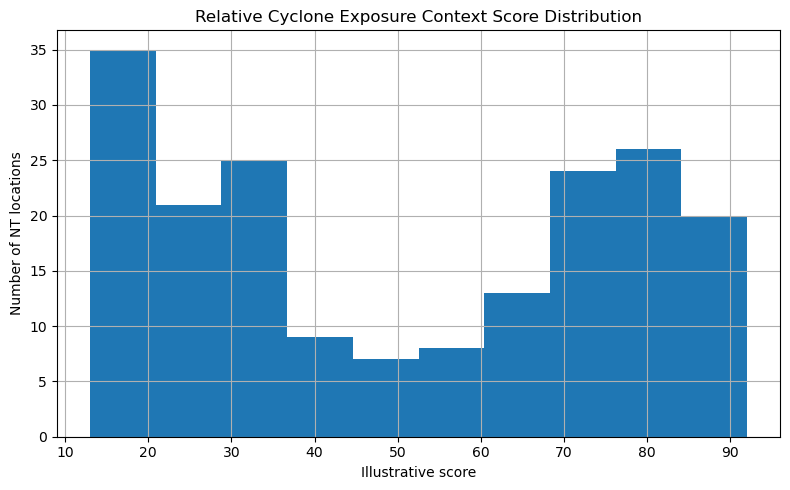

In [15]:
plt.figure(
    figsize=(8, 5)
)

mobile_cyclone[
    "cyclone_exposure_context_score"
].hist(
    bins=10
)

plt.title(
    "Relative Cyclone Exposure Context Score Distribution"
)

plt.xlabel(
    "Illustrative score"
)

plt.ylabel(
    "Number of NT locations"
)

plt.tight_layout()
plt.show()

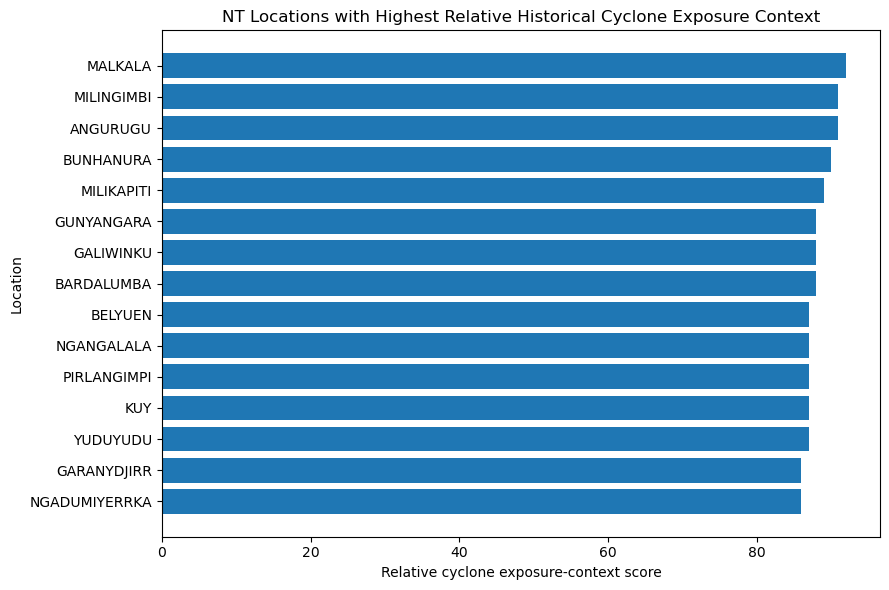

In [16]:
plot_data = (
    mobile_cyclone
    .sort_values(
        "cyclone_exposure_context_score",
        ascending=False
    )
    .head(15)
    .sort_values(
        "cyclone_exposure_context_score"
    )
)

plt.figure(
    figsize=(9, 6)
)

plt.barh(
    plot_data["site_name"],
    plot_data[
        "cyclone_exposure_context_score"
    ]
)

plt.title(
    "NT Locations with Highest Relative Historical Cyclone Exposure Context"
)

plt.xlabel(
    "Relative cyclone exposure-context score"
)

plt.ylabel(
    "Location"
)

plt.tight_layout()
plt.show()

## 16. Export data for NT Connect

Outputs:

- `data/cleaned/nt_mobile_coverage_with_cyclones.csv`
- `data/app/mobile_locations_with_cyclones.json`
- `outputs/cyclone_location_summary.csv`

In [17]:
clean_csv = (
    CLEAN_DIR
    / "nt_mobile_coverage_with_cyclones.csv"
)

app_json = (
    APP_DATA_DIR
    / "mobile_locations_with_cyclones.json"
)

summary_csv = (
    OUTPUT_DIR
    / "cyclone_location_summary.csv"
)

export_df = pd.DataFrame(
    mobile_cyclone.drop(
        columns=["geometry"],
        errors="ignore"
    )
)

if (
    "latest_cyclone_within_200km_date"
    in export_df.columns
):
    export_df[
        "latest_cyclone_within_200km_date"
    ] = (
        pd.to_datetime(
            export_df[
                "latest_cyclone_within_200km_date"
            ],
            errors="coerce",
            utc=True
        )
        .dt.strftime(
            "%Y-%m-%d"
        )
    )

export_df.to_csv(
    clean_csv,
    index=False
)

export_df.to_json(
    app_json,
    orient="records",
    indent=2,
    force_ascii=False
)

top_cyclone_locations.drop(
    columns=["geometry"],
    errors="ignore"
).to_csv(
    summary_csv,
    index=False
)

print("✅ Saved:")
print(clean_csv)
print(app_json)
print(summary_csv)

print(
    "\n🎉 CYCLONE ANALYSIS COMPLETE"
)

✅ Saved:
C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\cleaned\nt_mobile_coverage_with_cyclones.csv
C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\data\app\mobile_locations_with_cyclones.json
C:\Users\HP\OneDrive\เอกสาร\remote-connectivity\outputs\cyclone_location_summary.csv

🎉 CYCLONE ANALYSIS COMPLETE


## Interpretation

Use statements such as:

> “Historical BOM tropical cyclone tracks passed within X km of this location.”

Do **not** describe the score as a probability or prediction of cyclone damage.

The current layer does not independently represent:
- storm surge
- rainfall
- local wind exposure
- building vulnerability
- emergency response capacity
- future climate conditions

For NT Connect, it should be presented as **historical resilience context**.